In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy import stats
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/lung_disease_v1.csv')
display(df.head())

,patient_id,age,sex,bmi,smoking_status,pack_years,pm25_exposure,occupation,family_history,cough,...,dlco_pct_pred,cxr_finding,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hypertension,diabetes,hospital_visits_last_year,disease_type,severity
0,1,49,Male,20.1,Never,21.0,20.8,Office,NaN,1,...,82.1,Normal,3.0,11.9,447,1,1,0,Asthma,Moderate
1,2,61,Female,28.4,Current,34.1,10.8,Office,NaN,0,...,81.1,Normal,5.9,2.1,394,0,0,0,Lung Cancer,Mild/None
2,3,70,Male,22.2,Current,15.7,12.0,Manufacturing,NaN,1,...,85.4,Consolidation,2.8,4.8,309,0,1,0,Pneumonia,Mild/None
3,4,47,Male,23.1,Current,49.0,20.0,Manufacturing,NaN,0,...,49.0,Normal,1.8,29.4,190,0,0,0,COPD,Moderate
4,5,70,Female,29.0,Former,6.0,6.0,Office,NaN,0,...,81.6,Normal,1.0,9.5,314,0,0,0,Healthy,Mild/None


# **Task 1 :  Exploratory Data Analysis**

## Target Variable Distribution

 Target Variable Distribution (disease_type) : 
--------------------------------------------------
disease_type
Healthy        4243
COPD           2147
Asthma         1968
Pneumonia      1861
Lung Cancer    1781
Name: count, dtype: int64
 
 
 Percentage Distribution : 
--------------------------------------------------
disease_type
Healthy        35.36
COPD           17.89
Asthma         16.40
Pneumonia      15.51
Lung Cancer    14.84
Name: proportion, dtype: float64


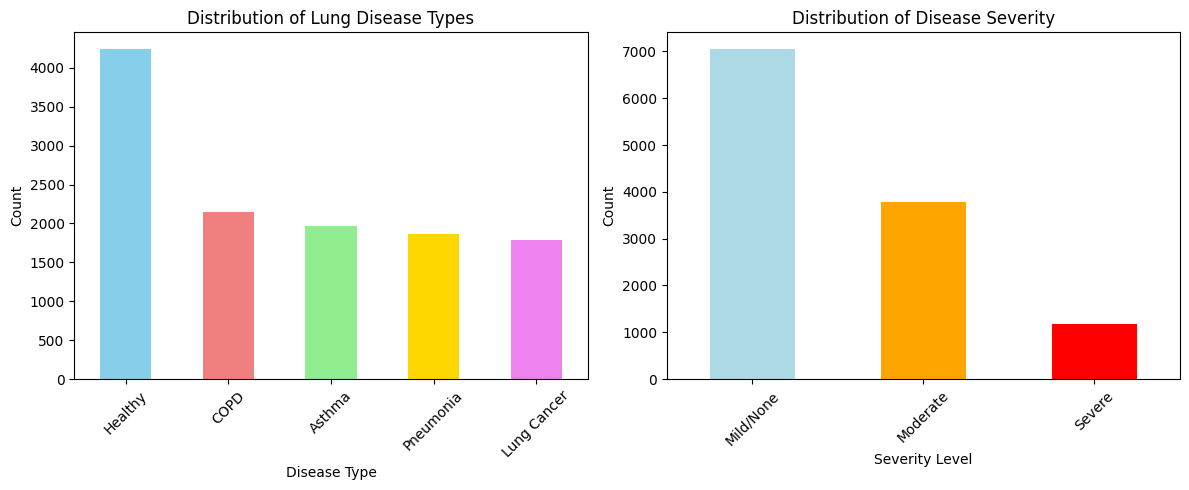

In [5]:
print(" Target Variable Distribution (disease_type) : ")
print("-" * 50)
print(df['disease_type'].value_counts())

print(" \n ")

print(" Percentage Distribution : ")
print("-" * 50)
print((df['disease_type'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['disease_type'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'violet'])
plt.title('Distribution of Lung Disease Types')
plt.xlabel('Disease Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['severity'].value_counts().plot(kind='bar', color=['lightblue', 'orange', 'red'])
plt.title('Distribution of Disease Severity')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Descriptive Statistics for Key Numerical Features

In [6]:
print(" Descriptive Statistics for Key Numerical Features: ")
print("-" * 50)

numerical_features = ['age', 'bmi', 'pack_years', 'pm25_exposure',
                      'weight_loss_kg', 'spo2', 'respiratory_rate',
                      'crp_mg_L', 'wbc_10e9_L', 'fev1_fvc',
                      'fev1_pct_pred', 'fvc_pct_pred', 'dlco_pct_pred',
                      'ct_nodule_size_mm', 'ct_emphysema_pct', 'sixmwd_m',
                      'hospital_visits_last_year']

desc_stats = df[numerical_features].describe().T
desc_stats['skewness'] = df[numerical_features].skew()
desc_stats['kurtosis'] = df[numerical_features].kurtosis()
print(desc_stats.round(2))

 Descriptive Statistics for Key Numerical Features: 
--------------------------------------------------
                             count    mean     std    min     25%     50%  \
age                        12000.0   58.07   14.74  18.00   48.00   58.00   
bmi                        12000.0   27.01    4.96  16.00   23.50   27.00   
pack_years                 12000.0   14.77   14.85   0.00    2.70   10.30   
pm25_exposure              12000.0   15.11    6.69   3.00   10.30   15.00   
weight_loss_kg             12000.0    1.62    2.42  -5.00    0.00    1.40   
spo2                       12000.0   95.96    2.38  87.20   94.40   96.00   
respiratory_rate           12000.0   17.97    2.99  10.00   15.90   18.00   
crp_mg_L                   12000.0   20.79   30.61   0.00    1.50   10.30   
wbc_10e9_L                 12000.0    8.10    2.61   2.00    6.30    7.80   
fev1_fvc                   12000.0    0.74    0.10   0.32    0.68    0.75   
fev1_pct_pred              12000.0   83.81   18.7

## Visualizations for Trends, Outliers, and Skewness

### Histograms

 Visualizing Histograms : 
--------------------------------------------------


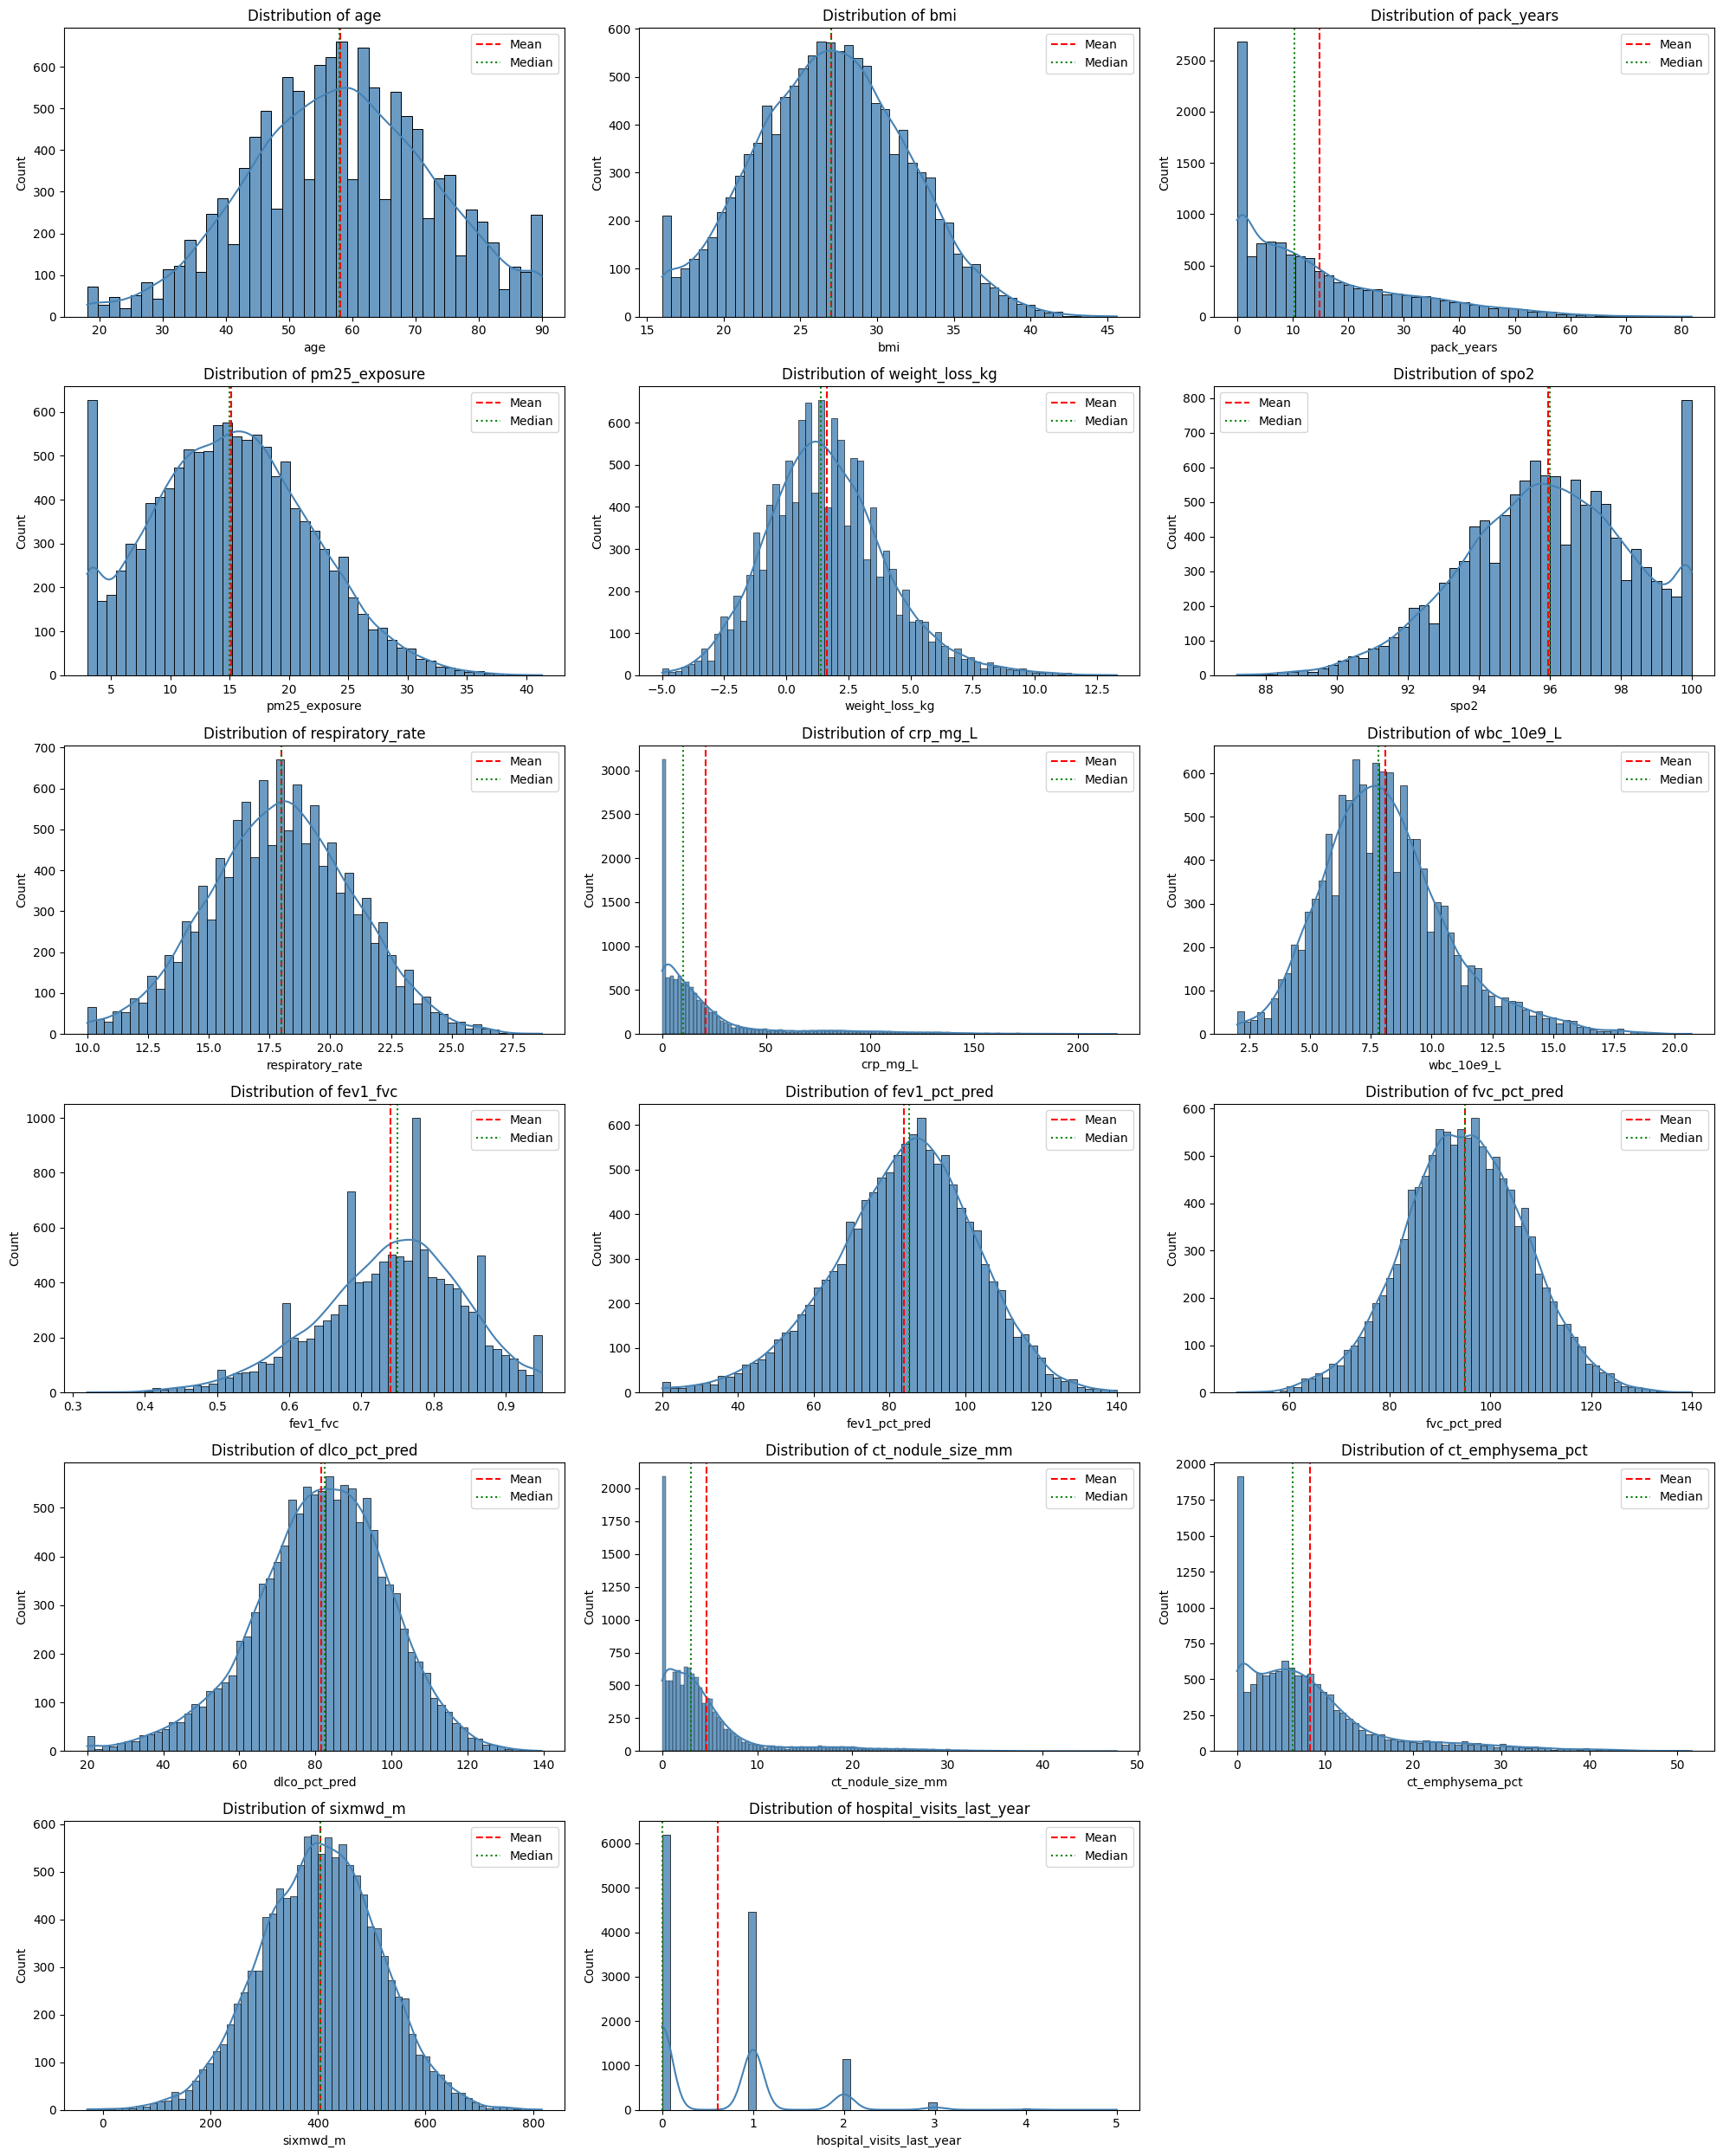

In [7]:
print(" Visualizing Histograms : ")
print("-" * 50)

plt.figure(figsize=(20, 25))

for i, col in enumerate(numerical_features):
    plt.subplot(6, 3, i + 1)

    # Subplots for Histograms
    sns.histplot(df[col], kde=True, color='steelblue', alpha=0.8)

    # Vertical Line for Mean & Median
    plt.axvline(df[col].mean(), color='red', linestyle='dashed', label='Mean')
    plt.axvline(df[col].median(), color='green', linestyle='dotted', label='Median')

    plt.title(f'Distribution of {col}')
    plt.legend()

plt.tight_layout()
plt.show()

### Box Plots

 Visualizing Boxplots : 
--------------------------------------------------


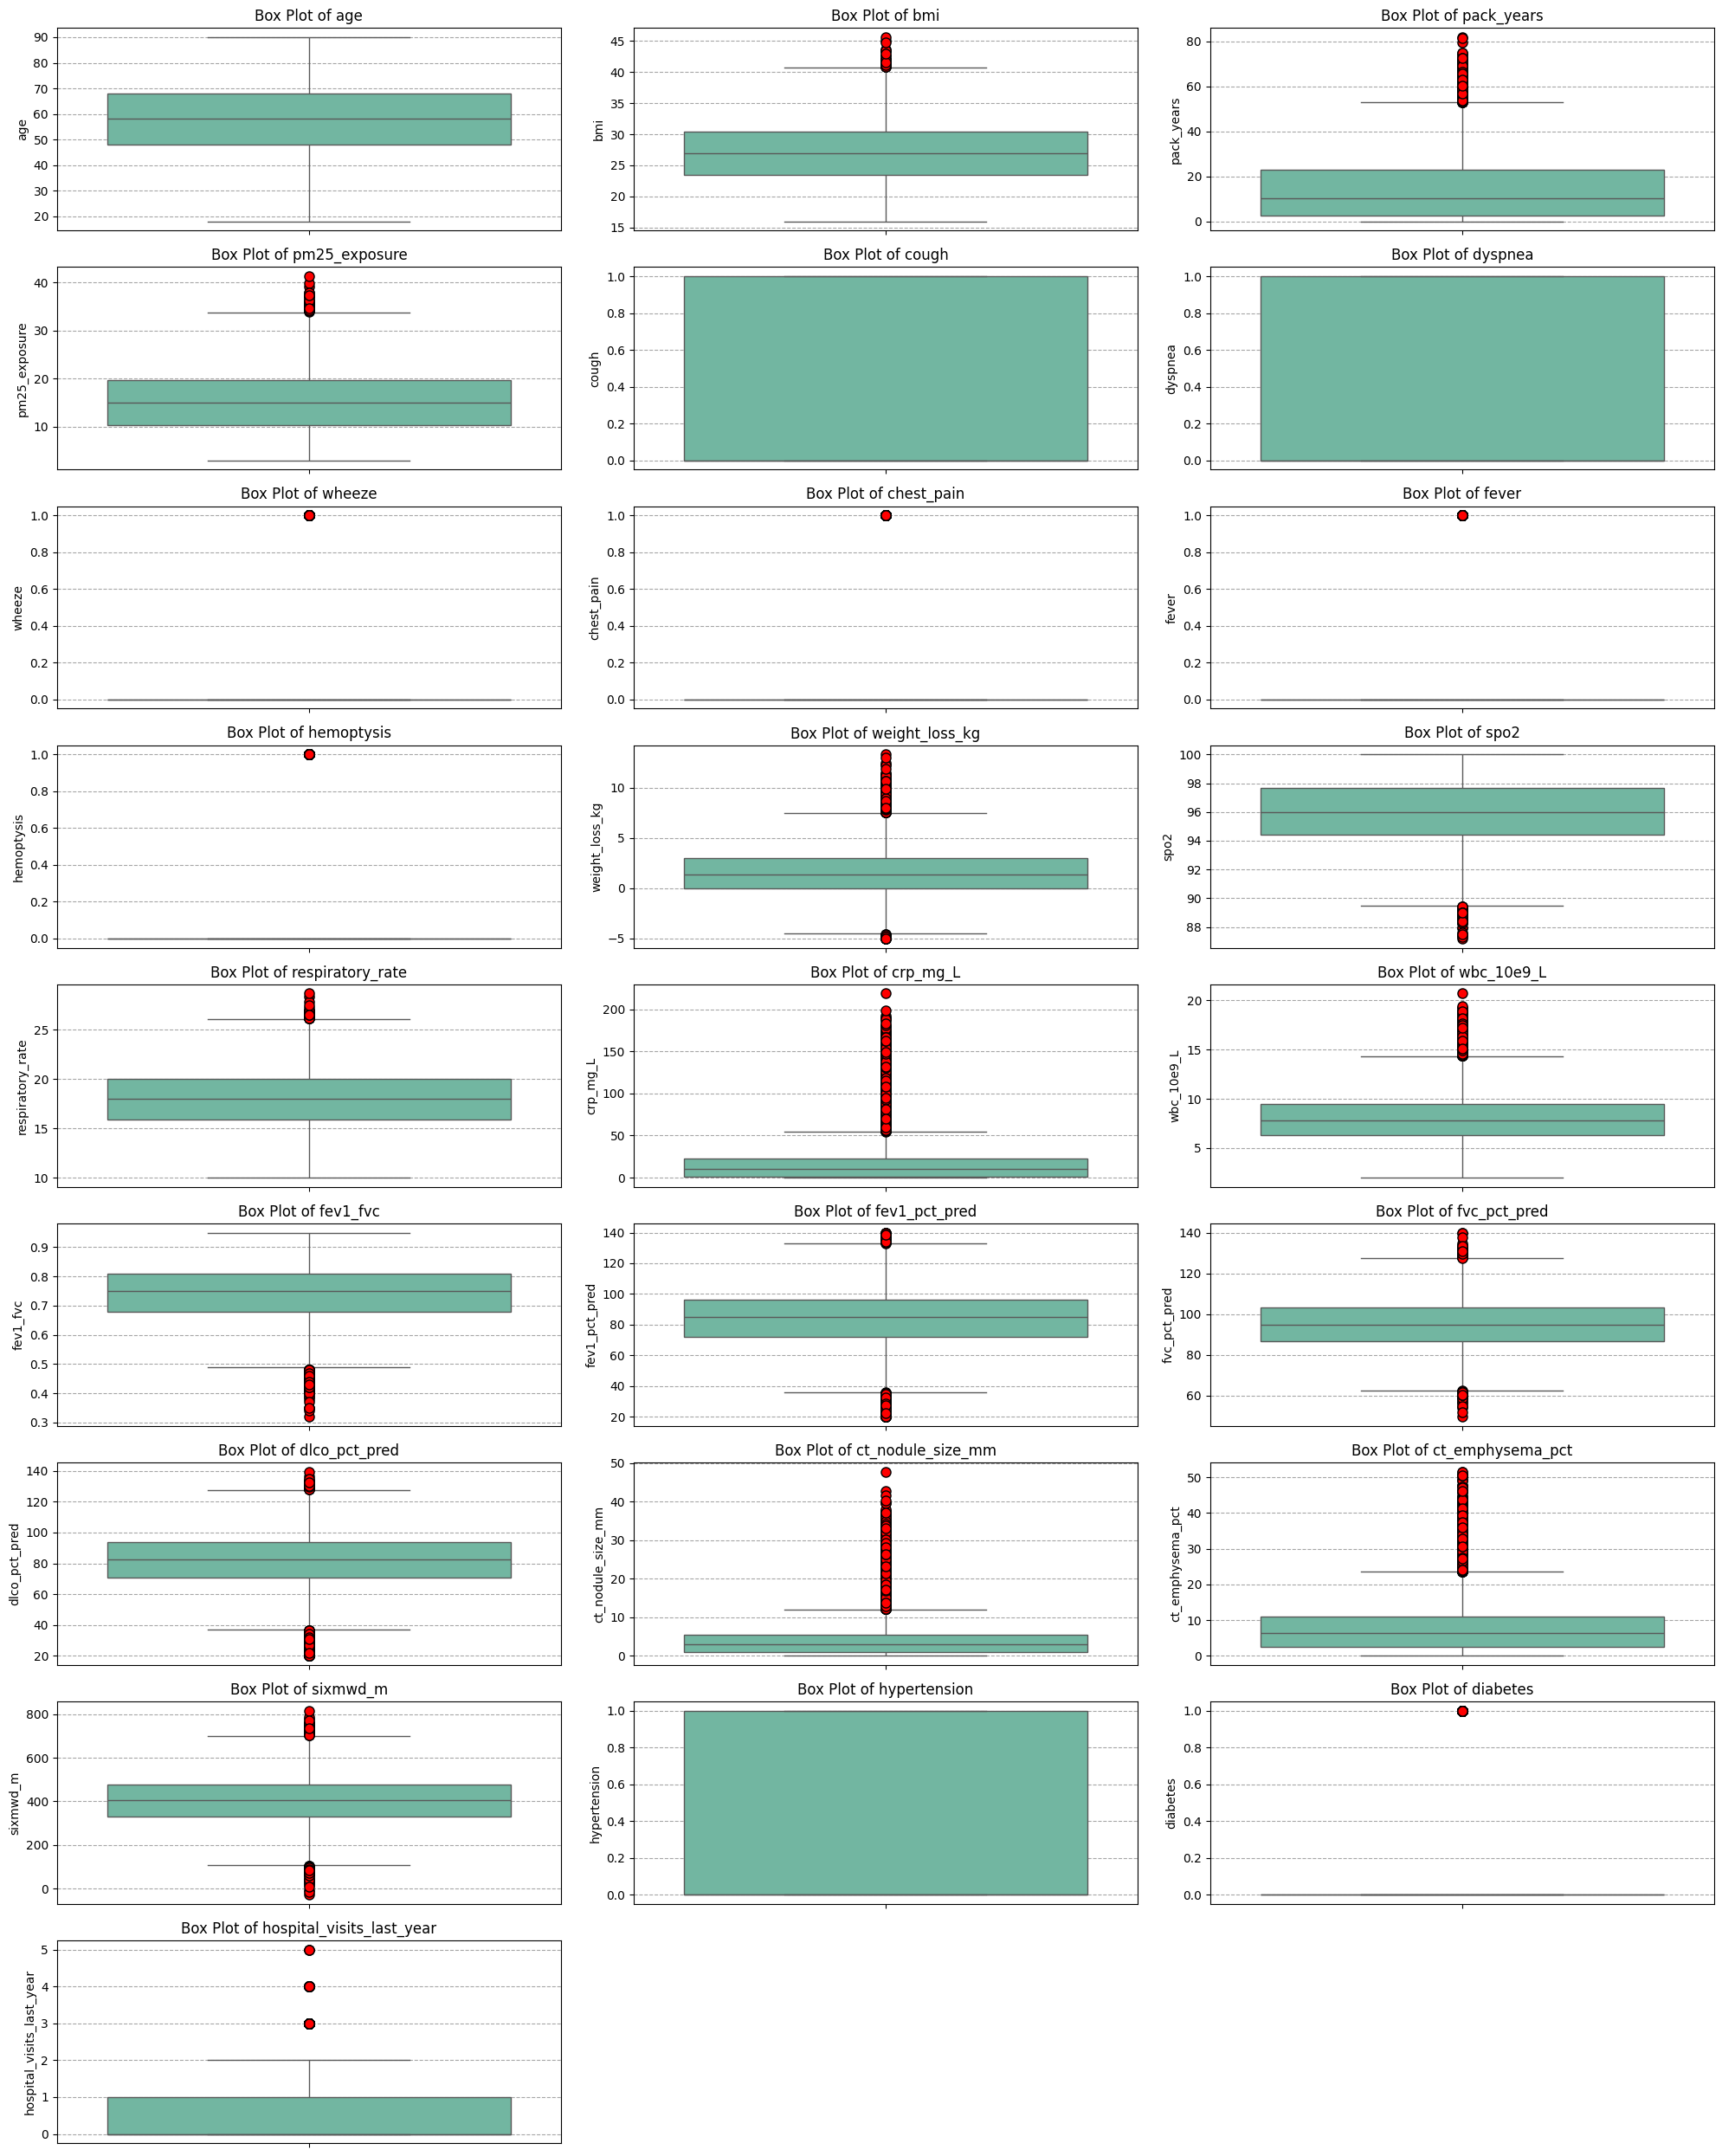

In [8]:
print(" Visualizing Boxplots : ")
print("-" * 50)

numerical_cols_for_box = df.select_dtypes(include=[np.number]).columns.drop(['patient_id'])

plt.figure(figsize=(20, 25))

for i, col in enumerate(numerical_cols_for_box):
    plt.subplot(9, 3, i + 1)
    sns.boxplot(y=df[col], palette='Set2', fliersize=8, flierprops={"markerfacecolor": "red", "markeredgecolor": "black"})
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='dashed', color='grey', alpha=0.7)

plt.tight_layout()
plt.show()

### Bar Charts

 Visualizing Bar Charts : 
--------------------------------------------------


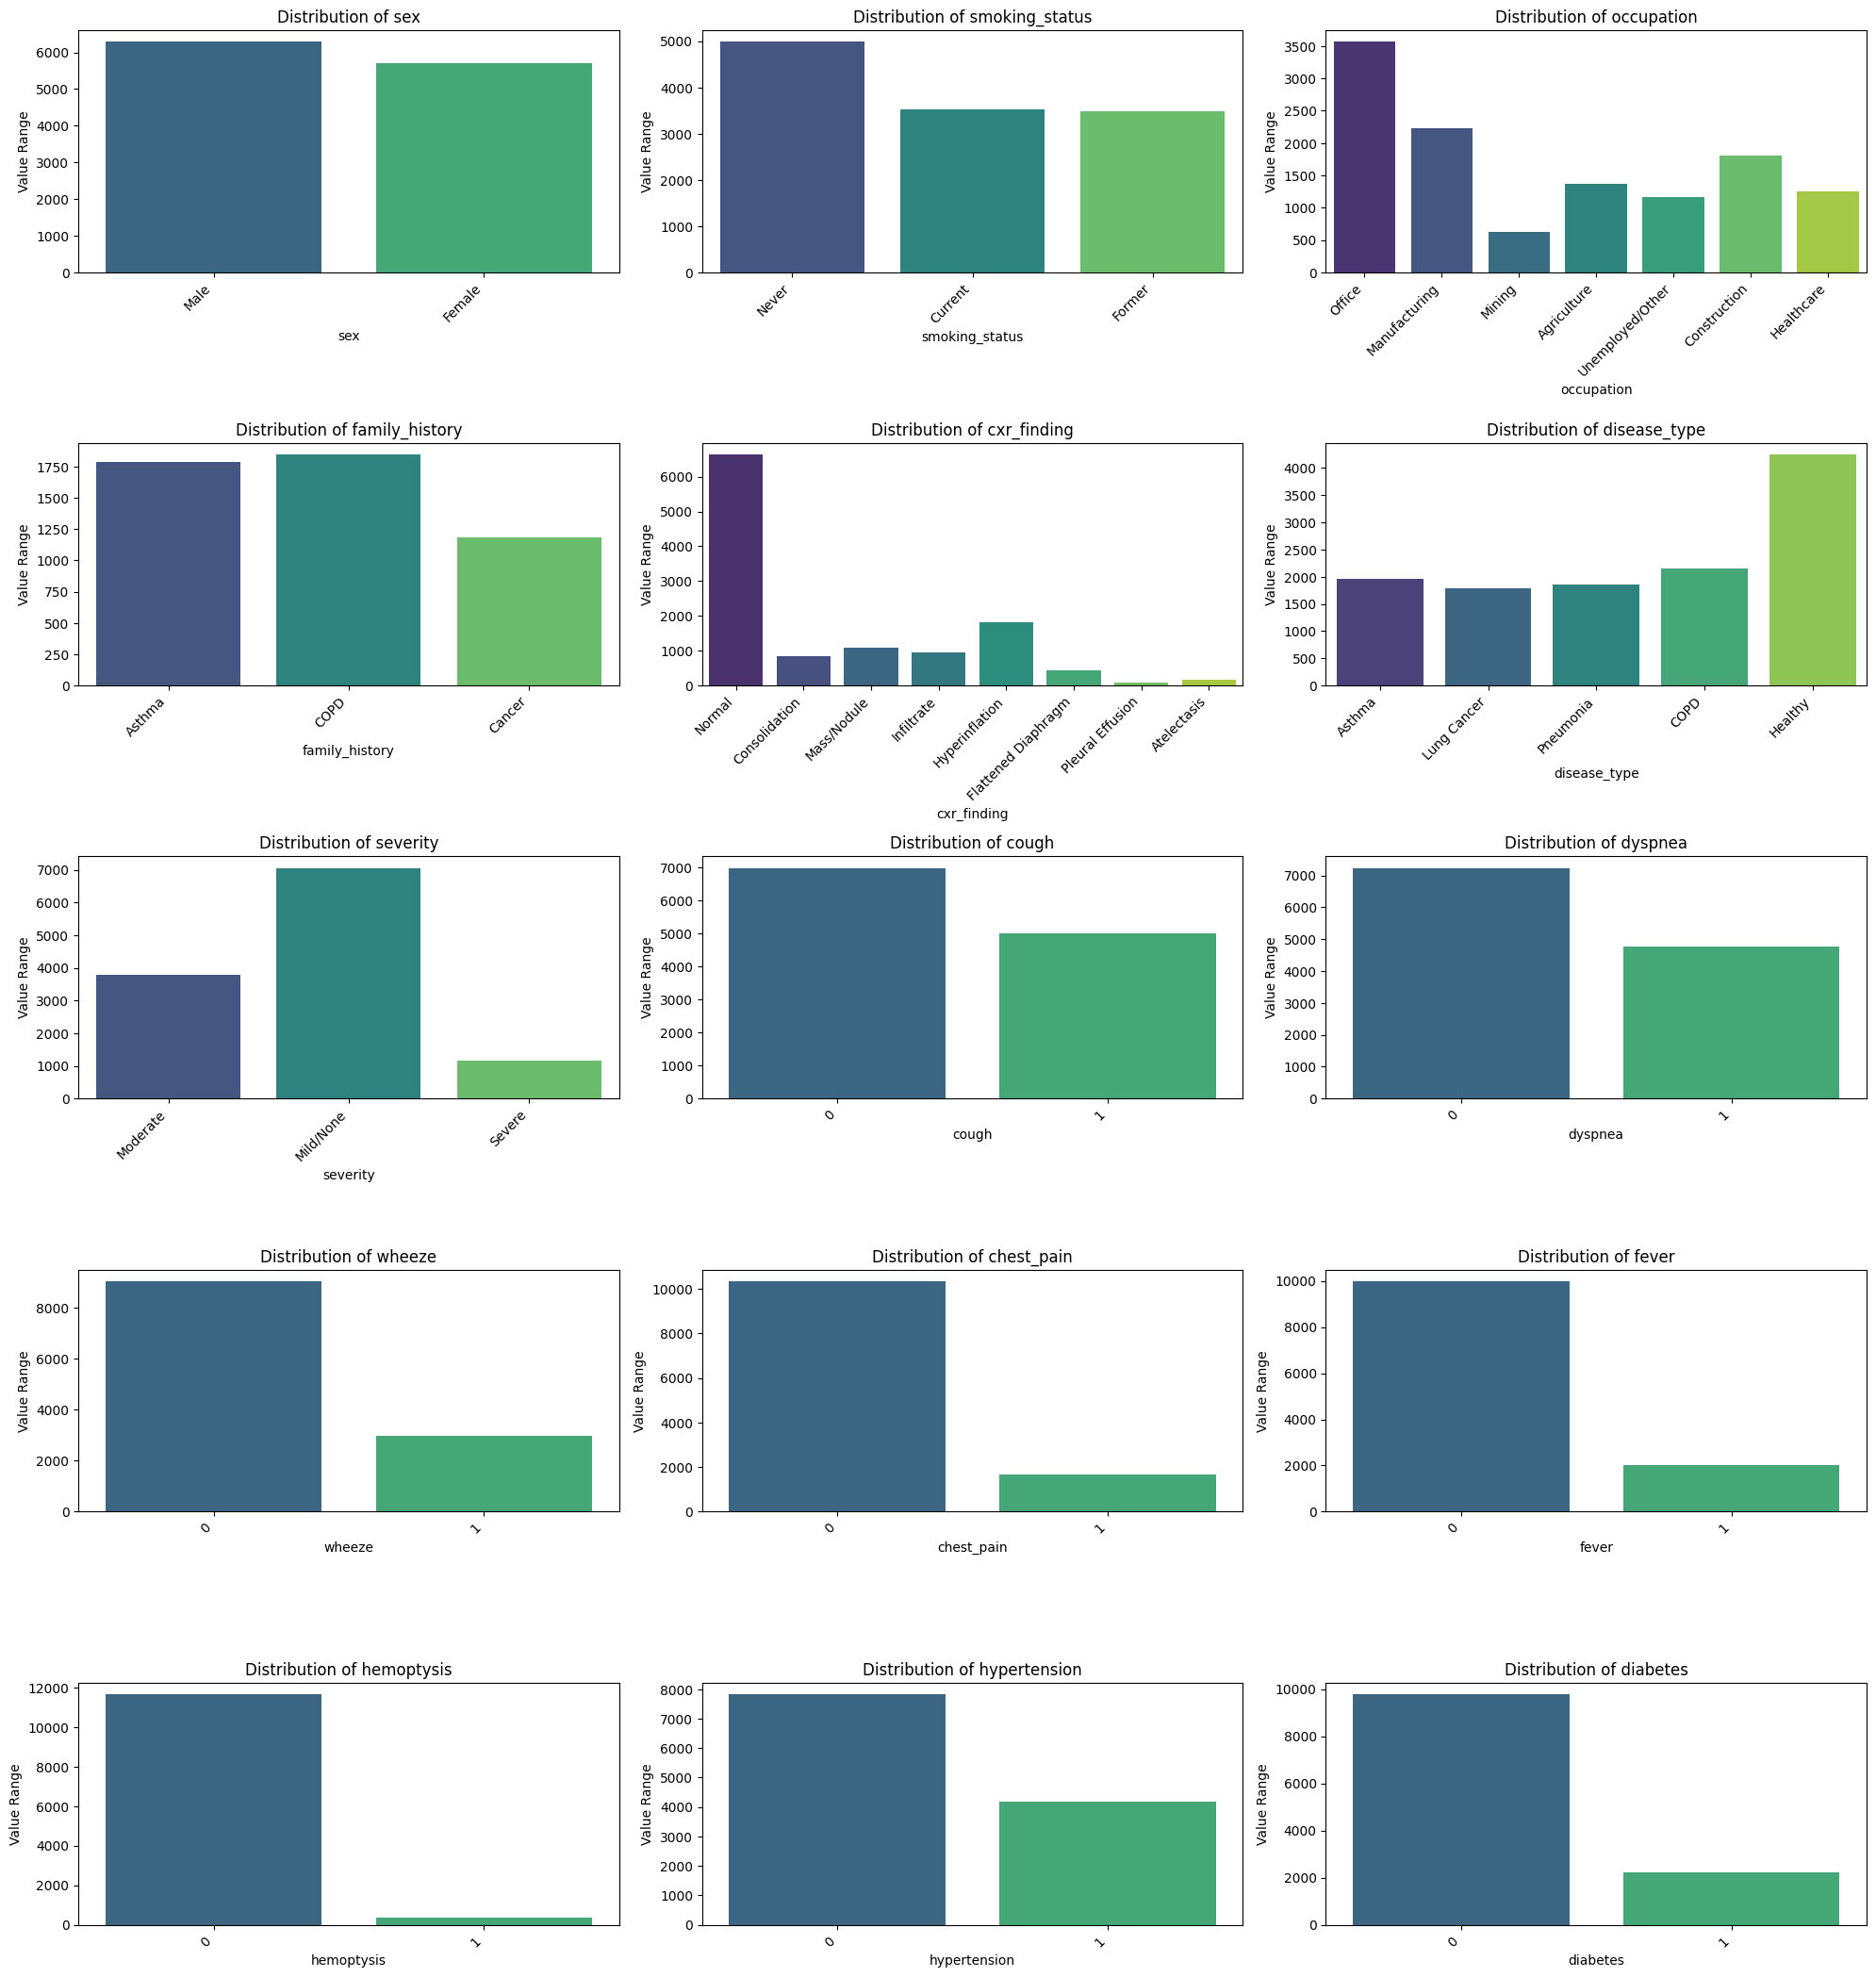

In [9]:
print(" Visualizing Bar Charts : ")
print("-" * 50)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
binary_numerical_cols = ['cough', 'dyspnea', 'wheeze', 'chest_pain', 'fever', 'hemoptysis', 'hypertension', 'diabetes']

all_categorical_like_cols = categorical_cols + binary_numerical_cols

plt.figure(figsize=(20, 25))

for i, col in enumerate(all_categorical_like_cols):
  plt.subplot(6, 3, i + 1)
  sns.countplot(x=col, data=df, palette='viridis')
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Value Range')
  plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Correlation Analysis

In [10]:
print(" Correlation Analysis : ")
print("-" * 50)

le = LabelEncoder()
df['disease_type_encoded'] = le.fit_transform(df['disease_type'])

correlation_matrix = df[numerical_features + ['disease_type_encoded']].corr()

print(" Correlations with 'disease_type_encoded' : ")
print("-" * 50)
display(correlation_matrix['disease_type_encoded'].sort_values(ascending=False))

 Correlation Analysis : 
--------------------------------------------------
 Correlations with 'disease_type_encoded' : 
--------------------------------------------------


,disease_type_encoded
disease_type_encoded,1.000000
crp_mg_L,0.592178
wbc_10e9_L,0.388916
fev1_fvc,0.372064
fev1_pct_pred,0.338662
ct_nodule_size_mm,0.242620
dlco_pct_pred,0.167489
weight_loss_kg,0.087517
pack_years,0.061260
sixmwd_m,0.007802


 Plot Heatmap : 
--------------------------------------------------


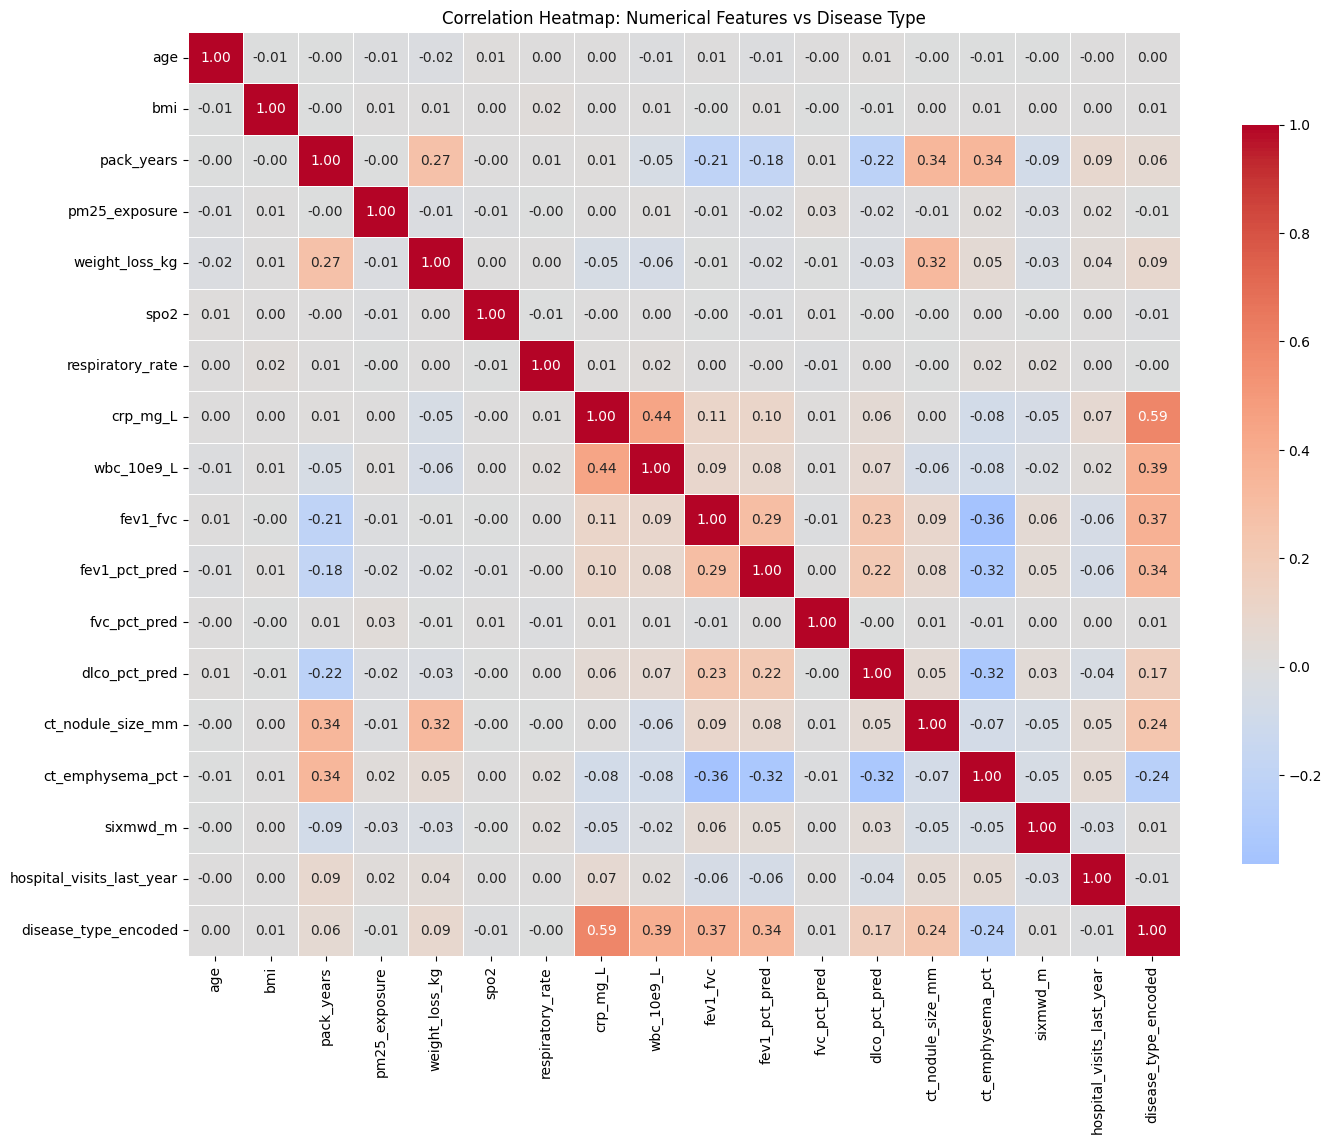

In [11]:
print(" Plot Heatmap : ")
print("-" * 50)

plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap: Numerical Features vs Disease Type')
plt.show()

## Features Linked to Specific Disease Categories

 Features Linked to Specific Disease Categories : 
--------------------------------------------------


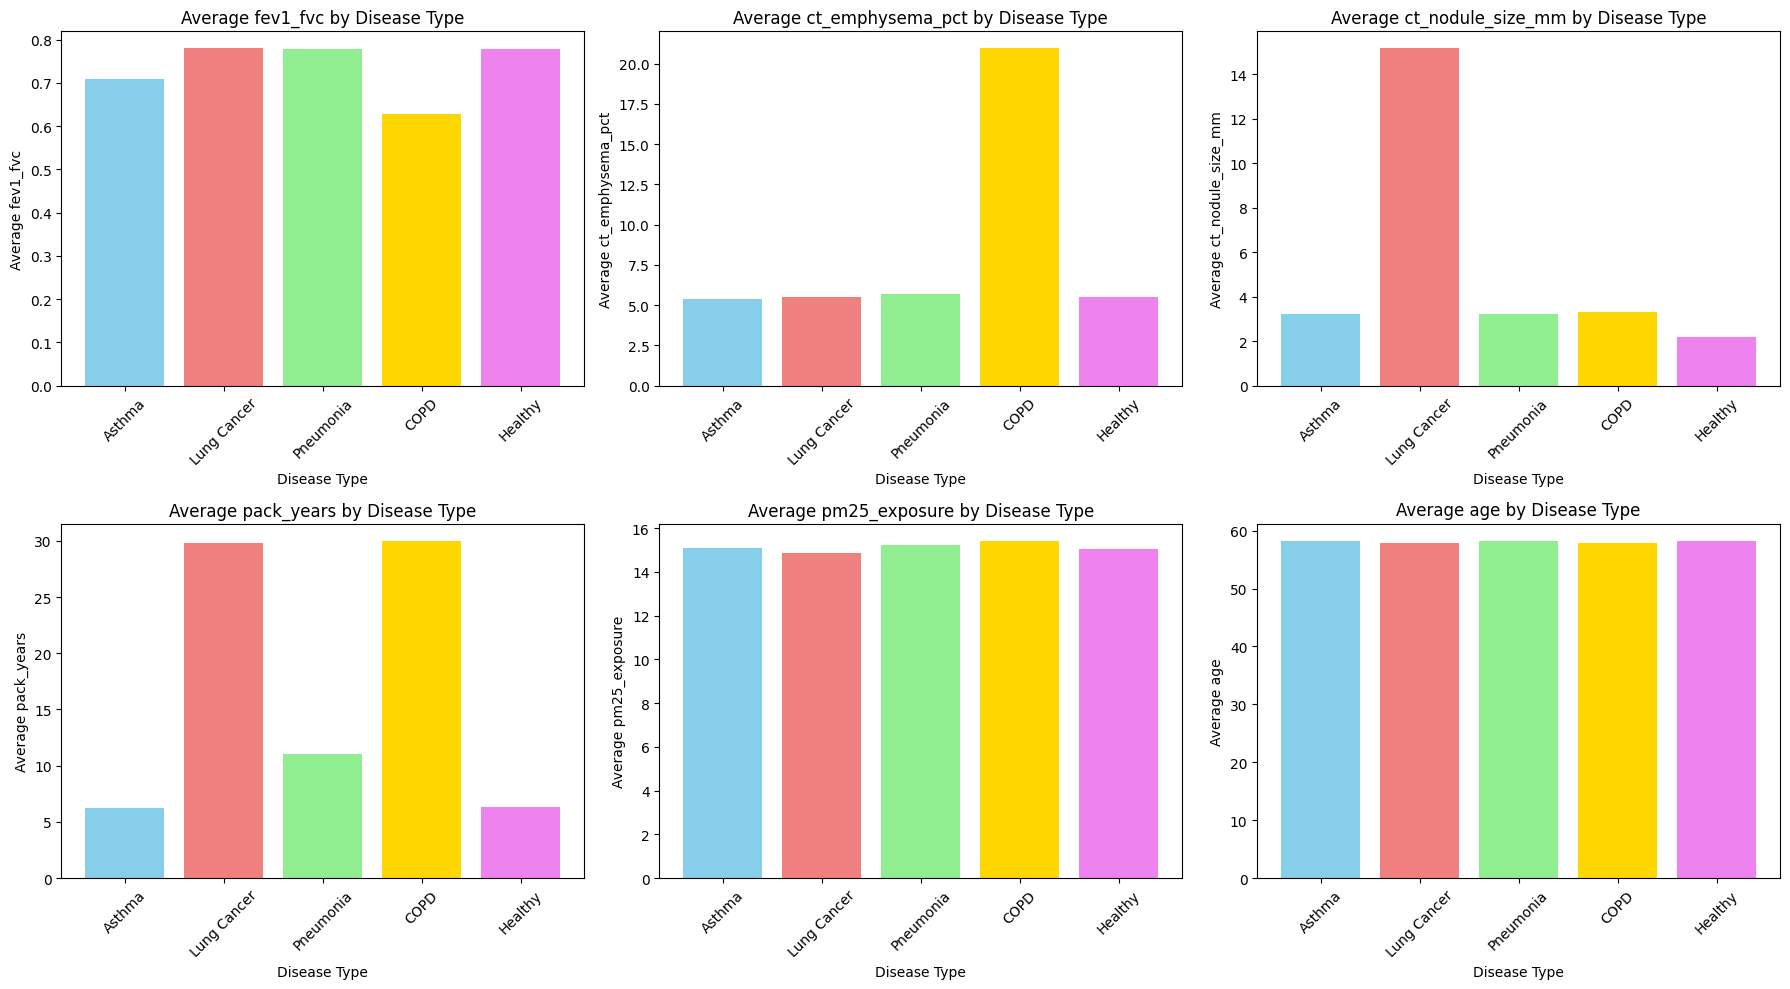

In [12]:
print(" Features Linked to Specific Disease Categories : ")
print("-" * 50)

disease_groups = df.groupby('disease_type')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
diseases = df['disease_type'].unique()

features_to_analyze = ['fev1_fvc', 'ct_emphysema_pct', 'ct_nodule_size_mm', 'pack_years', 'pm25_exposure', 'age']

for idx, feature in enumerate(features_to_analyze):
    ax = axes[idx//3, idx%3]
    disease_means = []

    for disease in diseases:
        disease_data = df[df['disease_type'] == disease][feature]
        disease_means.append(disease_data.mean())

    ax.bar(diseases, disease_means, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'violet'])
    ax.set_title(f'Average {feature} by Disease Type')
    ax.set_xlabel('Disease Type')
    ax.set_ylabel(f'Average {feature}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
print(" ANOVA Test for Feature Differences Across Disease Types : ")
print("-" * 50)

for feature in ['fev1_fvc', 'ct_nodule_size_mm', 'pack_years']:
    groups = [df[df['disease_type'] == disease][feature].dropna() for disease in diseases]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"{feature} : F-statistic = {f_stat:.2f}, p-value = {p_value:.4f}")


 ANOVA Test for Feature Differences Across Disease Types : 
--------------------------------------------------
fev1_fvc : F-statistic = 1489.28, p-value = 0.0000
ct_nodule_size_mm : F-statistic = 3749.45, p-value = 0.0000
pack_years : F-statistic = 3220.64, p-value = 0.0000


# **Task 2 : Data Preparation**

## Identify Missing Values

In [14]:
print(" Missing Values Analysis : ")
print("-" * 50)

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df) * 100)

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

print(missing_df[missing_df['Missing Values'] > 0])

 Missing Values Analysis : 
--------------------------------------------------
                Missing Values  Percentage
family_history            7176        59.8


## Handle missing values

In [15]:
print(" Handling Missing Values : ")
print("-" * 50)

print(" Strategy : Numerical Features - Median Imputation ")
print("-" * 50)

print(" Strategy : Categorical Features - Mode Imputation")
print("-" * 50)

original_shape = df.shape

categorical_cols = ['sex', 'smoking_status', 'occupation', 'family_history', 'cxr_finding', 'disease_type', 'severity']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['patient_id', 'disease_type_encoded']]

numerical_with_missing = [col for col in numerical_cols if df[col].isnull().sum() > 0]

if len(numerical_with_missing) > 0:
    print(f" Numerical Columns With Missing Values : {numerical_with_missing}")
    for col in numerical_with_missing:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f" {col}: Filled {df[col].isnull().sum()} Missing Values With Median = {median_val:.2f}")

categorical_with_missing = [col for col in categorical_cols if df[col].isnull().sum() > 0]

if len(categorical_with_missing) > 0:
    print(f" Categorical Columns With Missing Values : {categorical_with_missing}")
    for col in categorical_with_missing:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f" Filled Missing Values With Mode = '{mode_val}'")

print(f" Missing Values After Imputation : {df.isnull().sum().sum()}")


 Handling Missing Values : 
--------------------------------------------------
 Strategy : Numerical Features - Median Imputation 
--------------------------------------------------
 Strategy : Categorical Features - Mode Imputation
--------------------------------------------------
 Categorical Columns With Missing Values : ['family_history']
 Filled Missing Values With Mode = 'COPD'
 Missing Values After Imputation : 0


## Encode Categorical Variables

In [16]:
print(" Encoding Categorical Variables : ")
print("-" * 50)

df_encoded = df.copy()

nominal_cols = ['sex', 'smoking_status', 'occupation', 'cxr_finding', 'family_history']
print(" One-Hot Encoding For : ", nominal_cols)

print(" Before Encoding (First 3 Rows) : ")
print("-" * 50)
print(df_encoded[nominal_cols].head(3))

df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)

print("-" * 50)
print(" After Encoding (First 3 Rows of New Columns) : ")
print("-" * 50)
encoded_cols = [col for col in df_encoded.columns if any(nom in col for nom in nominal_cols)]
print(df_encoded[encoded_cols[:5]].head(3))

 Encoding Categorical Variables : 
--------------------------------------------------
 One-Hot Encoding For :  ['sex', 'smoking_status', 'occupation', 'cxr_finding', 'family_history']
 Before Encoding (First 3 Rows) : 
--------------------------------------------------
      sex smoking_status     occupation    cxr_finding family_history
0    Male          Never         Office         Normal           COPD
1  Female        Current         Office         Normal           COPD
2    Male        Current  Manufacturing  Consolidation           COPD
--------------------------------------------------
 After Encoding (First 3 Rows of New Columns) : 
--------------------------------------------------
   sex_Male  smoking_status_Former  smoking_status_Never  \
0      True                  False                  True   
1     False                  False                 False   
2      True                  False                 False   

   occupation_Construction  occupation_Healthcare  
0     

In [17]:
print(" Label Encoding For : disease_type, severity ")
print("-" * 50)

le_disease = LabelEncoder()
le_severity = LabelEncoder()

print(" Before Label Encoding : ")
print("-" * 50)
print(" disease_type Unique Values : ", df['disease_type'].unique())
print(" severity Unique Values : ", df['severity'].unique())

df_encoded['disease_type_encoded'] = le_disease.fit_transform(df['disease_type'])
df_encoded['severity_encoded'] = le_severity.fit_transform(df['severity'])

print("-" * 50)
print(" After Label Encoding : ")
print("-" * 50)
print(" disease_type_encoded Mapping : ", dict(zip(le_disease.classes_, le_disease.transform(le_disease.classes_))))
print(" severity_encoded Mapping : ", dict(zip(le_severity.classes_, le_severity.transform(le_severity.classes_))))

 Label Encoding For : disease_type, severity 
--------------------------------------------------
 Before Label Encoding : 
--------------------------------------------------
 disease_type Unique Values :  ['Asthma' 'Lung Cancer' 'Pneumonia' 'COPD' 'Healthy']
 severity Unique Values :  ['Moderate' 'Mild/None' 'Severe']
--------------------------------------------------
 After Label Encoding : 
--------------------------------------------------
 disease_type_encoded Mapping :  {'Asthma': np.int64(0), 'COPD': np.int64(1), 'Healthy': np.int64(2), 'Lung Cancer': np.int64(3), 'Pneumonia': np.int64(4)}
 severity_encoded Mapping :  {'Mild/None': np.int64(0), 'Moderate': np.int64(1), 'Severe': np.int64(2)}


## Scale Numerical Variables

In [18]:
print(" Scaling Numerical Variables : ")
print("-" * 50)

numerical_to_scale = [col for col in numerical_cols if col not in ['disease_type_encoded', 'severity_encoded']]

print(f" Scaling {len(numerical_to_scale)} Numerical Features Using StandardScaler ")

print("-" * 50)
print(" Before Scaling (First 3 Rows) : ")
print("-" * 50)
print(df_encoded[numerical_to_scale[:5]].head(3).round(2))

original_values = df_encoded[numerical_to_scale].copy()

scaler = StandardScaler()
df_encoded[numerical_to_scale] = scaler.fit_transform(df_encoded[numerical_to_scale])

print("-" * 50)
print(" After Scaling (First 3 Rows) : ")
print("-" * 50)
print(df_encoded[numerical_to_scale[:5]].head(3).round(2))

print("-" * 50)
print(" Scaling Effect Demonstration (age Column) : ")
print("-" * 50)
print(f" Original - Mean : {original_values['age'].mean():.2f}, Std: {original_values['age'].std():.2f}")
print(f" Scaled   - Mean : {df_encoded['age'].mean():.2f}, Std: {df_encoded['age'].std():.2f}")

 Scaling Numerical Variables : 
--------------------------------------------------
 Scaling 25 Numerical Features Using StandardScaler 
--------------------------------------------------
 Before Scaling (First 3 Rows) : 
--------------------------------------------------
   age   bmi  pack_years  pm25_exposure  cough
0   49  20.1        21.0           20.8      1
1   61  28.4        34.1           10.8      0
2   70  22.2        15.7           12.0      1
--------------------------------------------------
 After Scaling (First 3 Rows) : 
--------------------------------------------------
    age   bmi  pack_years  pm25_exposure  cough
0 -0.62 -1.39        0.42           0.85   1.18
1  0.20  0.28        1.30          -0.64  -0.85
2  0.81 -0.97        0.06          -0.47   1.18
--------------------------------------------------
 Scaling Effect Demonstration (age Column) : 
--------------------------------------------------
 Original - Mean : 58.07, Std: 14.74
 Scaled   - Mean : 0.00, Std

#**Task 3 : Model Training**

## Prepare Features and Target

In [19]:
print(" Preparing Features and Target Variable : ")
print("-" * 50)

target_column = 'disease_type_encoded'

exclude_columns = ['patient_id', 'disease_type', 'severity', 'disease_type_encoded', 'severity_encoded']
feature_columns = [col for col in df_encoded.columns if col not in exclude_columns]

X = df_encoded[feature_columns]
y = df_encoded[target_column]

print(f" Number of Features : {X.shape[1]}")
print(f" Number of Samples : {X.shape[0]}")
print(f" Target Classes : {len(np.unique(y))}")
print(f" Feature Columns : {X.columns.tolist()[:10]}...")

 Preparing Features and Target Variable : 
--------------------------------------------------
 Number of Features : 43
 Number of Samples : 12000
 Target Classes : 5
 Feature Columns : ['age', 'bmi', 'pack_years', 'pm25_exposure', 'cough', 'dyspnea', 'wheeze', 'chest_pain', 'fever', 'hemoptysis']...


## Split Dataset (80/20 Ratio)

In [20]:
print(" Splitting Dataset Into Train (80%) and Test (20%) Sets:")
print("-" * 50)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f" Training Set Size : {X_train.shape[0]} Samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f" Test Set Size : {X_test.shape[0]} Samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f" Class Distribution in Training Set : {np.bincount(y_train)}")
print(f" Class Distribution in Test set : {np.bincount(y_test)}")

 Splitting Dataset Into Train (80%) and Test (20%) Sets:
--------------------------------------------------
 Training Set Size : 9600 Samples (80.0%)
 Test Set Size : 2400 Samples (20.0%)
 Class Distribution in Training Set : [1574 1718 3394 1425 1489]
 Class Distribution in Test set : [394 429 849 356 372]


## Train Multiple Classification Algorithms

In [21]:
print(" Training Multiple Classification Algorithms : ")
print("-" * 50)

models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Support Vector Machine' : SVC(random_state=42, probability=True),
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Random Forest' : RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42)
}

trained_models = {}
initial_params = {}

print(" Training Models With Default Hyperparameters ... ")
for name, model in models.items():
  print("-" * 50)
  print(f" Training {name} ... ")

  initial_params[name] = model.get_params()

  model.fit(X_train, y_train)
  trained_models[name] = model

  print(f" {name} Trained Successfully! ")


 Training Multiple Classification Algorithms : 
--------------------------------------------------
 Training Models With Default Hyperparameters ... 
--------------------------------------------------
 Training Logistic Regression ... 
 Logistic Regression Trained Successfully! 
--------------------------------------------------
 Training Support Vector Machine ... 
 Support Vector Machine Trained Successfully! 
--------------------------------------------------
 Training Decision Tree ... 
 Decision Tree Trained Successfully! 
--------------------------------------------------
 Training Random Forest ... 
 Random Forest Trained Successfully! 
--------------------------------------------------
 Training K-Nearest Neighbors ... 
 K-Nearest Neighbors Trained Successfully! 
--------------------------------------------------
 Training Gradient Boosting ... 
 Gradient Boosting Trained Successfully! 


In [22]:
print(" Initial Hyperparameters For Each Model : ")
print("-" * 50)

for name, params in initial_params.items():
  print("-" * 50)
  print(f" {name} : ")
  key_params = {k: v for k, v in params.items() if 'random_state' in k or 'max_depth' in k or 'n_estimators' in k or 'C' in k or 'kernel' in k or 'n_neighbors' in k}

  for param, value in key_params.items():
    print(f"  {param} : {value} ")

 Initial Hyperparameters For Each Model : 
--------------------------------------------------
--------------------------------------------------
 Logistic Regression : 
  C : 1.0 
  random_state : 42 
--------------------------------------------------
 Support Vector Machine : 
  C : 1.0 
  kernel : rbf 
  random_state : 42 
--------------------------------------------------
 Decision Tree : 
  max_depth : None 
  random_state : 42 
--------------------------------------------------
 Random Forest : 
  max_depth : None 
  n_estimators : 100 
  random_state : 42 
--------------------------------------------------
 K-Nearest Neighbors : 
  n_neighbors : 5 
--------------------------------------------------
 Gradient Boosting : 
  max_depth : 3 
  n_estimators : 100 
  random_state : 42 


# **Task 4 : Model Evaluation and Visualtization**

## Evaluate All Models

In [23]:
print(" Evaluating All Models : ")
print("-" * 50)

results = []

for name, model in trained_models.items():
  y_pred = model.predict(X_test)
  y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  f1 = f1_score(y_test, y_pred, average='weighted')

  if y_pred_proba is not None:
    try:
      auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    except:
      auc_roc = np.nan
    else:
      auc_roc = np.nan

  results.append({
      'Model' : name,
      'Accuracy' : accuracy,
      'Precision' : precision,
      'Recall' : recall,
      'F1-Score' : f1,
      'AUC-ROC' : auc_roc
    })

  print("-" * 50)
  print(f" {name} : ")
  print(f"  Accuracy :  {accuracy:.4f}")
  print(f"  Precision : {precision:.4f}")
  print(f"  Recall :    {recall:.4f}")
  print(f"  F1-Score :  {f1:.4f}")
  print(f"  AUC-ROC :   {auc_roc:.4f}")

 Evaluating All Models : 
--------------------------------------------------
--------------------------------------------------
 Logistic Regression : 
  Accuracy :  0.9371
  Precision : 0.9370
  Recall :    0.9371
  F1-Score :  0.9367
  AUC-ROC :   nan
--------------------------------------------------
 Support Vector Machine : 
  Accuracy :  0.9333
  Precision : 0.9338
  Recall :    0.9333
  F1-Score :  0.9332
  AUC-ROC :   nan
--------------------------------------------------
 Decision Tree : 
  Accuracy :  0.8762
  Precision : 0.8795
  Recall :    0.8762
  F1-Score :  0.8774
  AUC-ROC :   nan
--------------------------------------------------
 Random Forest : 
  Accuracy :  0.9371
  Precision : 0.9369
  Recall :    0.9371
  F1-Score :  0.9368
  AUC-ROC :   nan
--------------------------------------------------
 K-Nearest Neighbors : 
  Accuracy :  0.8621
  Precision : 0.8719
  Recall :    0.8621
  F1-Score :  0.8624
  AUC-ROC :   nan
-----------------------------------------------

In [24]:
results_df = pd.DataFrame(results)
print(" Comparative Performance Table : ")
print("-" * 50)
display(results_df.round(4).sort_values('Accuracy', ascending=False))

 Comparative Performance Table : 
--------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.9371,0.9370,0.9371,0.9367,NaN
3,Random Forest,0.9371,0.9369,0.9371,0.9368,NaN
1,Support Vector Machine,0.9333,0.9338,0.9333,0.9332,NaN
5,Gradient Boosting,0.9321,0.9317,0.9321,0.9316,NaN
2,Decision Tree,0.8762,0.8795,0.8762,0.8774,NaN
4,K-Nearest Neighbors,0.8621,0.8719,0.8621,0.8624,NaN


## Visual Diagnostics

 Visual Diagnostics : 
--------------------------------------------------


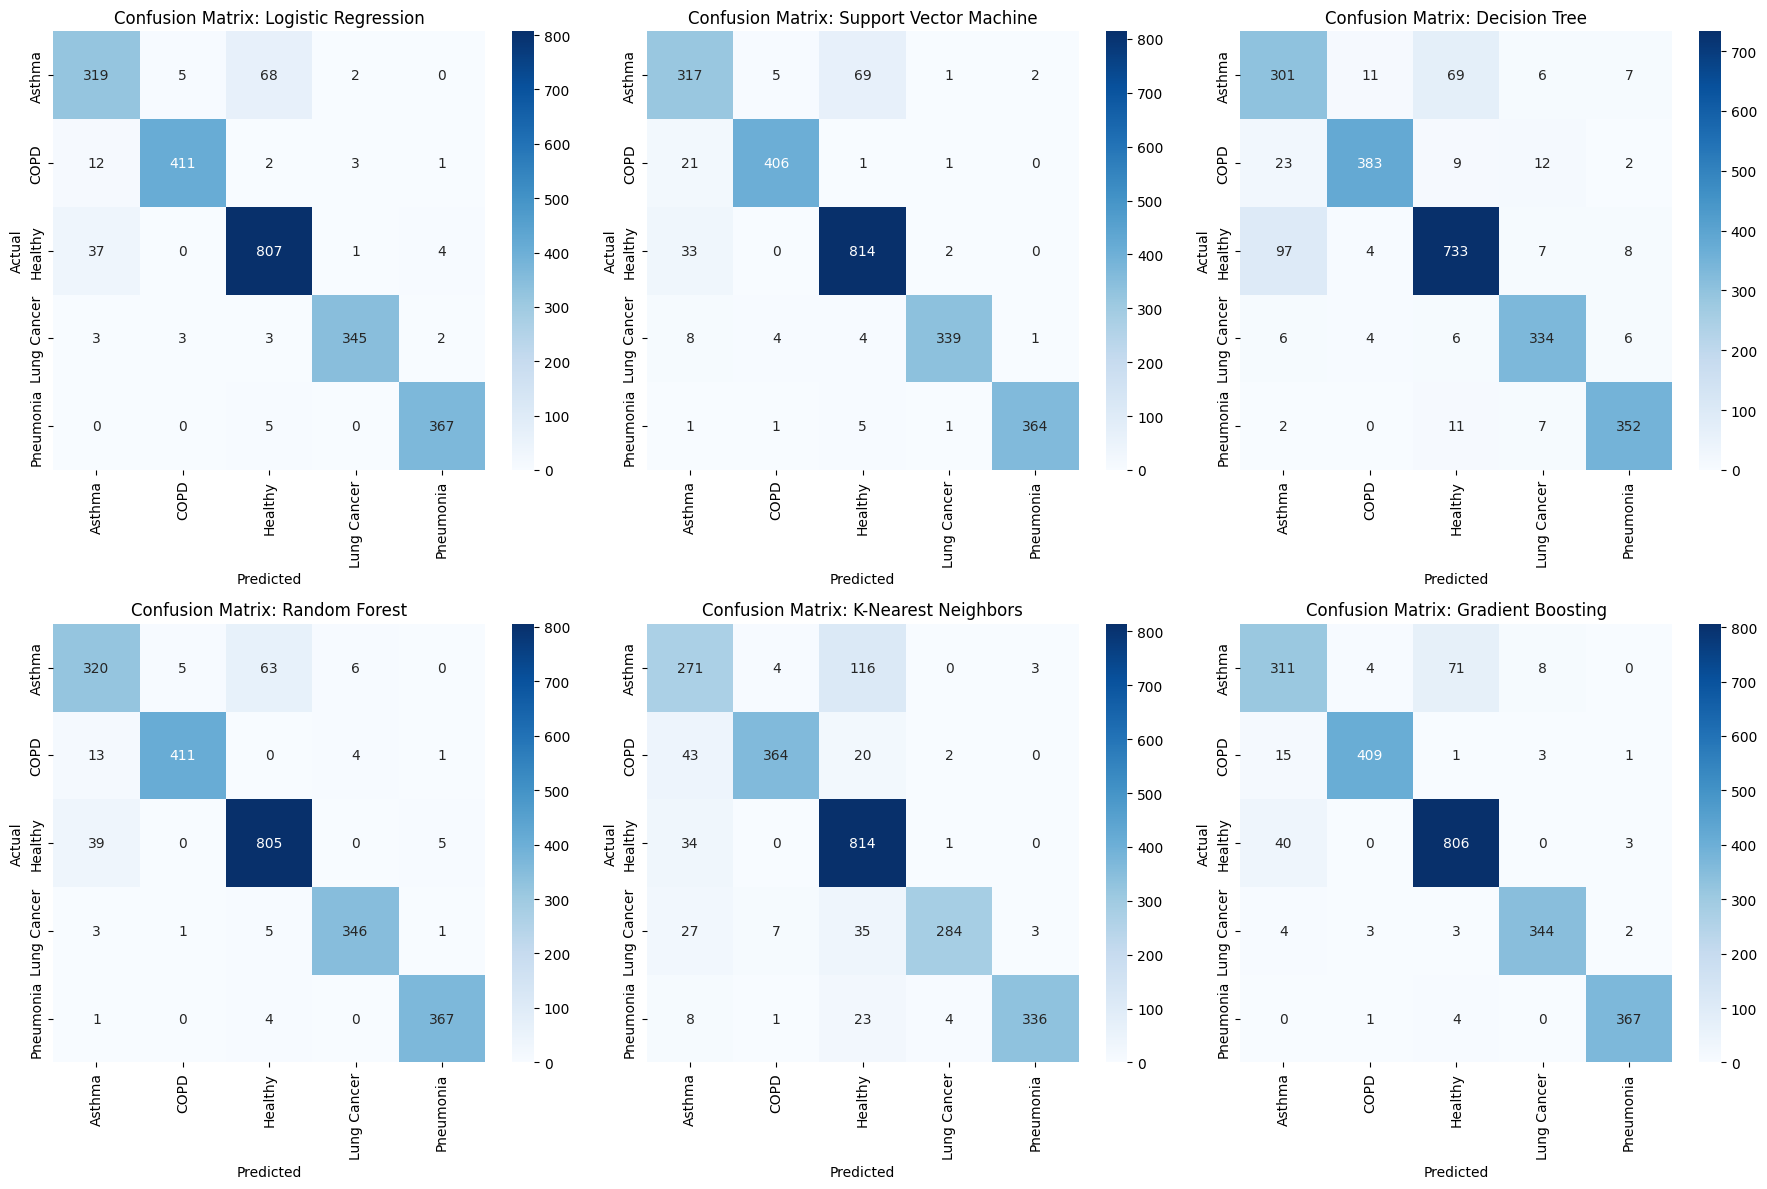

In [25]:
print(" Visual Diagnostics : ")
print("-" * 50)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(list(trained_models.items())[:6]):
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)

  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=le_disease.classes_, yticklabels=le_disease.classes_)

  axes[idx].set_title(f'Confusion Matrix: {name}')
  axes[idx].set_xlabel('Predicted')
  axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

 ROC Curves (Macro-Averaged) For All Models : 
--------------------------------------------------


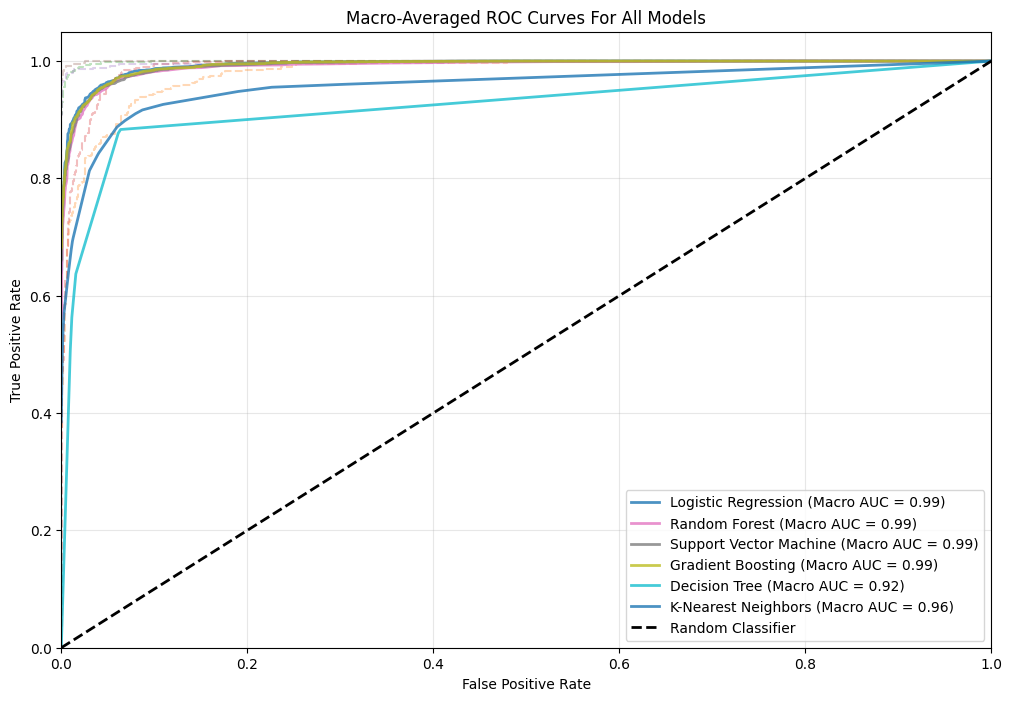

In [26]:
print(" ROC Curves (Macro-Averaged) For All Models : ")
print("-" * 50)

sorted_models = sorted(trained_models.items(), key=lambda x: accuracy_score(y_test, x[1].predict(X_test)), reverse=True)

plt.figure(figsize=(12, 8))

n_classes = len(le_disease.classes_)

y_test_bin = label_binarize(y_test, classes=range(n_classes))

for name, model in sorted_models[:6]:
  if hasattr(model, "predict_proba"):
    y_pred_proba = model.predict_proba(X_test)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
      y_true_binary = (y_test == i).astype(int)
      y_score_binary = y_pred_proba[:, i]

      fpr[i], tpr[i], _ = roc_curve(y_true_binary, y_score_binary)
      roc_auc[i] = roc_auc_score(y_true_binary, y_score_binary)

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
      mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes

    roc_auc_macro = roc_auc_score(y_test_bin, y_pred_proba, average="macro")

    plt.plot(all_fpr, mean_tpr, label=f'{name} (Macro AUC = {roc_auc_macro:.2f})', linewidth=2, alpha=0.8)

    if name == sorted_models[0][0]:
      for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], linestyle='--', alpha=0.3, label=f'_nolegend_')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Averaged ROC Curves For All Models')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## Hyperparameter Tuning For Best Model

In [34]:
print(" Hyperparameter Tuning For Best Model : ")
print("-" * 50)

best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_model = trained_models[best_model_name]

print(f" Best Model For Tuning : {best_model_name}")
print(f" Initial Accuracy : {results_df.loc[results_df['Accuracy'].idxmax(), 'Accuracy']:.4f}")

 Hyperparameter Tuning For Best Model : 
--------------------------------------------------
 Best Model For Tuning : Logistic Regression
 Initial Accuracy : 0.9379


In [28]:
param_dist = {
    'C' : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver' : ['liblinear', 'saga'],
    'max_iter' : [100, 200, 500],
    'class_weight' : [None, 'balanced']
}

print(f" Performing RandomizedSearch For : {best_model_name} ")
print("-" * 50)

start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=best_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

end_time = time.time()
print(f" RandomizedSearch Completed in : {end_time - start_time:.2f} Seconds ")

tuned_model = random_search.best_estimator_
best_params = random_search.best_params_

print(f" Best Parameters Found : ")

for param, value in best_params.items():
  print(f" {param} : {value}")

y_pred_tuned = tuned_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f" Performance Comparison : ")
print(f" Before Tuning : {results_df.loc[results_df['Accuracy'].idxmax(), 'Accuracy']:.4f}")
print(f" After Tuning :  {accuracy_tuned:.4f}")
print(f" Improvement :   {(accuracy_tuned - results_df.loc[results_df['Accuracy'].idxmax(), 'Accuracy']):.4f}")

results_df.loc[results_df['Model'] == best_model_name, 'Accuracy'] = accuracy_tuned

 Performing RandomizedSearch For : Logistic Regression 
--------------------------------------------------
Fitting 3 folds for each of 30 candidates, totalling 90 fits
 RandomizedSearch Completed in : 160.31 Seconds 
 Best Parameters Found : 
 solver : saga
 penalty : l1
 max_iter : 100
 class_weight : None
 C : 1
 Performance Comparison : 
 Before Tuning : 0.9371
 After Tuning :  0.9379
 Improvement :   0.0008


## Feature Importance Analysis

 Feature Importance Analysis : 
--------------------------------------------------
 Top 15 Most Important Features : 
                            Feature  Importance
36       cxr_finding_Hyperinflation      2.3843
37           cxr_finding_Infiltrate      1.7173
38          cxr_finding_Mass/Nodule      1.6722
13                         crp_mg_L      1.5847
39               cxr_finding_Normal      1.5101
2                        pack_years      1.4157
34        cxr_finding_Consolidation      1.1695
35  cxr_finding_Flattened Diaphragm      0.9813
19                ct_nodule_size_mm      0.8930
27             smoking_status_Never      0.6868
15                         fev1_fvc      0.6790
20                 ct_emphysema_pct      0.5853
16                    fev1_pct_pred      0.5315
8                             fever      0.4240
14                       wbc_10e9_L      0.4094


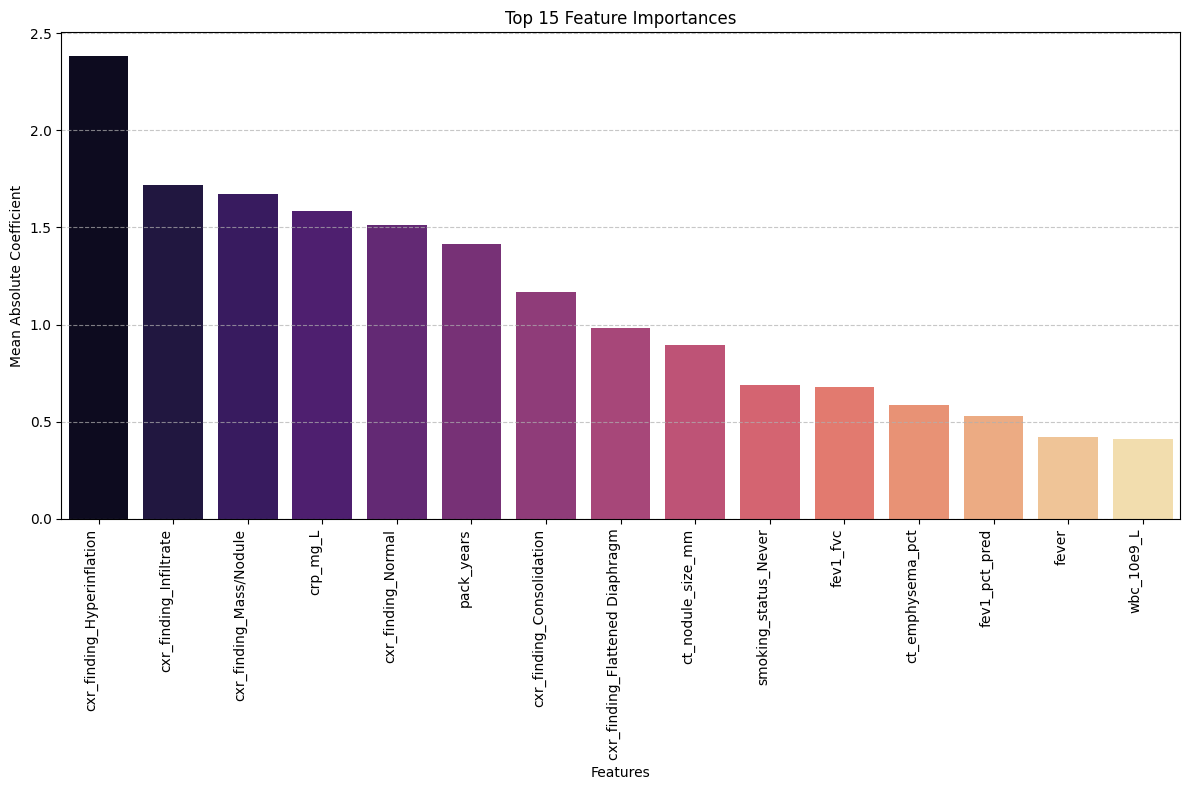

In [61]:
print(" Feature Importance Analysis : ")
print("-" * 50)

feature_names = X_train.columns

importance = np.mean(np.abs(tuned_model.coef_), axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values('Importance', ascending=False).head(15)

print(f" Top 15 Most Important Features : ")
print(importance_df.round(4))

plt.figure(figsize=(12, 8))
sns.barplot(x='Feature', y='Importance', data=importance_df, palette='magma')

plt.title(f'Top 15 Feature Importances')
plt.xlabel('Features')
plt.ylabel('Mean Absolute Coefficient')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

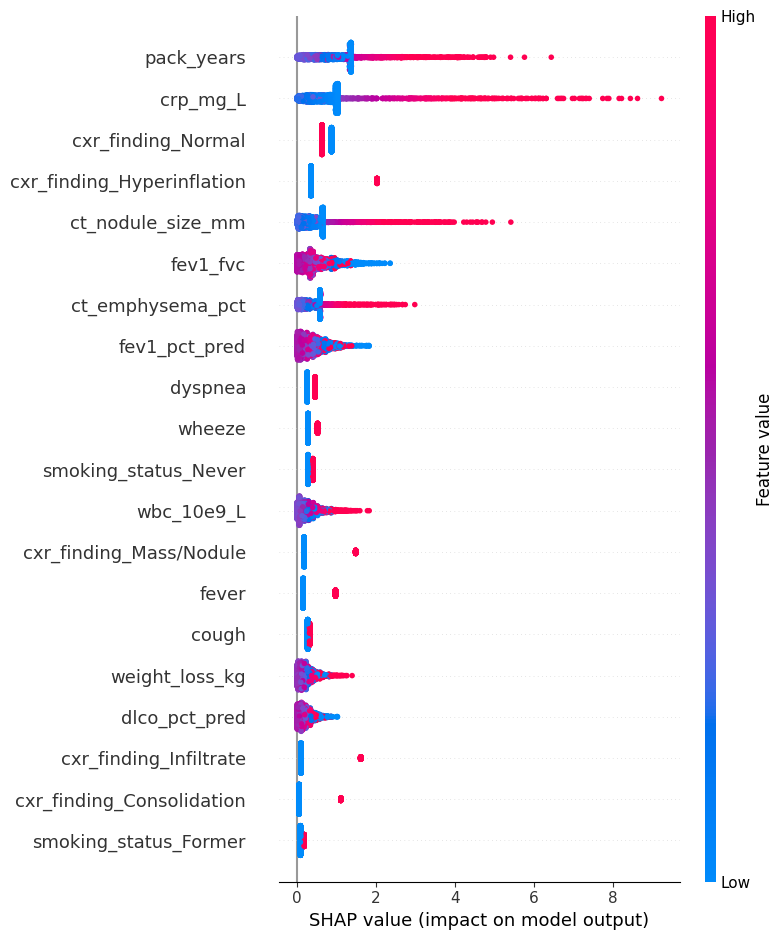

In [66]:
explainer = shap.LinearExplainer(tuned_model, X_train)
shap_values = explainer.shap_values(X_test)

shap_values = np.asarray(shap_values).astype(float)

aggregated_shap_values = np.mean(np.abs(shap_values), axis=2)

shap.summary_plot(aggregated_shap_values, X_test, feature_names=X.columns)

# **Task 5 : Conclusion**

# Summary of Findings

In [30]:
print(" Summary of Findings : ")
print("-" * 50)

best_overall = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"Best performing model: {best_overall['Model']}")
print(f"Accuracy: {best_overall['Accuracy']:.4f}")
print(f"Precision: {best_overall['Precision']:.4f}")
print(f"Recall: {best_overall['Recall']:.4f}")
print(f"F1-Score: {best_overall['F1-Score']:.4f}")
if not pd.isna(best_overall['AUC-ROC']):
  print(f"AUC-ROC: {best_overall['AUC-ROC']:.4f}")

 Summary of Findings : 
--------------------------------------------------
Best performing model: Logistic Regression
Accuracy: 0.9379
Precision: 0.9370
Recall: 0.9371
F1-Score: 0.9367


In [31]:
print(" Key Insights From Feature Importance Analysis :")
if 'importance_df' in locals():
  print(" Most Important Features for Disease Classification:")
  for idx, row in importance_df.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")


 Key Insights From Feature Importance Analysis :
 Most Important Features for Disease Classification:
  cxr_finding_Hyperinflation: 2.3843
  cxr_finding_Infiltrate: 1.7173
  cxr_finding_Mass/Nodule: 1.6722
  crp_mg_L: 1.5847
  cxr_finding_Normal: 1.5101


In [32]:
print(" Final Summary : ")
print("-" * 50)
print(f" Total Models Trained : {len(trained_models)}")
print(f" Best Model : {best_overall['Model']}")
print(f" Best Accuracy Achieved : {best_overall['Accuracy']:.4f}")
print(f" Total Features Used : {X.shape[1]}")

 Final Summary : 
--------------------------------------------------
 Total Models Trained : 6
 Best Model : Logistic Regression
 Best Accuracy Achieved : 0.9379
 Total Features Used : 43
